In [67]:
import pandas as pd

# Load the first dataset
df1 = pd.read_csv("../dataset/fake_reviews/fake_reviews.csv")

# Load the deceptive dataset
df2 = pd.read_csv("../dataset/deceptive/deceptive-opinion.csv")

print("========== Fake Reviews Dataset ==========")
print(df1.head())

print("\nColumns:")
print(df1.columns)

print("\n=========================================\n")

print("========== Deceptive Dataset ==========")
print(df2.head())

print("\nColumns:")
print(df2.columns)

========== Fake Reviews Dataset ==========
             category  rating label  \
0  Home_and_Kitchen_5     5.0    CG   
1  Home_and_Kitchen_5     5.0    CG   
2  Home_and_Kitchen_5     5.0    CG   
3  Home_and_Kitchen_5     1.0    CG   
4  Home_and_Kitchen_5     5.0    CG   

                                               text_  
0  Love this!  Well made, sturdy, and very comfor...  
1  love it, a great upgrade from the original.  I...  
2  This pillow saved my back. I love the look and...  
3  Missing information on how to use it, but it i...  
4  Very nice set. Good quality. We have had the s...  

Columns:
Index(['category', 'rating', 'label', 'text_'], dtype='str')


========== Deceptive Dataset ==========
  deceptive   hotel  polarity       source  \
0  truthful  conrad  positive  TripAdvisor   
1  truthful   hyatt  positive  TripAdvisor   
2  truthful   hyatt  positive  TripAdvisor   
3  truthful    omni  positive  TripAdvisor   
4  truthful   hyatt  positive  TripAdvisor   

  

In [68]:
# ==========================================
# Standardize Dataset 1
# ==========================================

df1 = df1.rename(columns={
    "text_": "review",
    "label": "label"
})

df1 = df1[["review", "label"]]


# Convert labels
df1["label"] = df1["label"].replace({
    "CG": "Fake",
    "OR": "Genuine"
})


print(df1.head())

                                              review label
0  Love this!  Well made, sturdy, and very comfor...  Fake
1  love it, a great upgrade from the original.  I...  Fake
2  This pillow saved my back. I love the look and...  Fake
3  Missing information on how to use it, but it i...  Fake
4  Very nice set. Good quality. We have had the s...  Fake


In [69]:
print(df1["label"].value_counts())

label
Fake       20216
Genuine    20216
Name: count, dtype: int64


In [70]:
# ==========================================
# Standardize Dataset 2
# ==========================================

df2 = df2.rename(columns={
    "text": "review"
})

df2 = df2[["review", "deceptive"]]

df2 = df2.rename(columns={
    "deceptive": "label"
})

df2["label"] = df2["label"].replace({
    "truthful": "Genuine",
    "deceptive": "Fake"
})

print(df2.head())
print(df2.columns)

                                              review    label
0  We stayed for a one night getaway with family ...  Genuine
1  Triple A rate with upgrade to view room was le...  Genuine
2  This comes a little late as I'm finally catchi...  Genuine
3  The Omni Chicago really delivers on all fronts...  Genuine
4  I asked for a high floor away from the elevato...  Genuine
Index(['review', 'label'], dtype='str')


In [71]:
print(df2["label"].value_counts())

label
Genuine    800
Fake       800
Name: count, dtype: int64


In [72]:
print("Dataset 1")
print(df1["label"].value_counts())

print("\n----------------------\n")

print("Dataset 2")
print(df2["label"].value_counts())

Dataset 1
label
Fake       20216
Genuine    20216
Name: count, dtype: int64

----------------------

Dataset 2
label
Genuine    800
Fake       800
Name: count, dtype: int64


In [73]:
print("Dataset 1 Missing Values")
print(df1.isnull().sum())

print("\n----------------------\n")

print("Dataset 2 Missing Values")
print(df2.isnull().sum())

Dataset 1 Missing Values
review    0
label     0
dtype: int64

----------------------

Dataset 2 Missing Values
review    0
label     0
dtype: int64


In [74]:
print("Dataset 1 Duplicate Reviews:")
print(df1.duplicated().sum())

print("\n----------------------\n")

print("Dataset 2 Duplicate Reviews:")
print(df2.duplicated().sum())

Dataset 1 Duplicate Reviews:
20

----------------------

Dataset 2 Duplicate Reviews:
4


In [75]:
# ==========================================
# Merge the Datasets
# ==========================================

merged_df = pd.concat([df1, df2], ignore_index=True)

print("Merged Dataset Shape:")
print(merged_df.shape)

print("\nFirst 5 Rows:")
print(merged_df.head())

print("\nLabel Distribution:")
print(merged_df["label"].value_counts())

Merged Dataset Shape:
(42032, 2)

First 5 Rows:
                                              review label
0  Love this!  Well made, sturdy, and very comfor...  Fake
1  love it, a great upgrade from the original.  I...  Fake
2  This pillow saved my back. I love the look and...  Fake
3  Missing information on how to use it, but it i...  Fake
4  Very nice set. Good quality. We have had the s...  Fake

Label Distribution:
label
Fake       21016
Genuine    21016
Name: count, dtype: int64


In [76]:
# ==========================================
# Shuffle Dataset
# ==========================================

merged_df = merged_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(merged_df.head())

                                              review    label
0  Nice product.  I bought expensive benjamin Moo...  Genuine
1  This was a very challenging time for the movie...     Fake
2  Nelson DeMille is my father's favorite author,...  Genuine
3  fits my f200 well. My brother is stoked cause ...  Genuine
4  Bought this after reading other reviews.  I ha...  Genuine


In [77]:
# ==========================================
# Save Merged Dataset
# ==========================================

merged_df.to_csv("../dataset/merged/merged_reviews.csv", index=False)

print("Merged dataset saved successfully!")

Merged dataset saved successfully!


In [78]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [79]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/harshavardhini/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/harshavardhini/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/harshavardhini/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [80]:
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

In [81]:
def clean_text(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+", "", text)

    # Remove HTML
    text = re.sub(r"<.*?>", "", text)

    # Remove Numbers
    text = re.sub(r"\d+", "", text)

    # Remove Punctuation
    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )

    # Remove Extra Spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize
    words = text.split()

    # Remove Stopwords
    words = [
        word
        for word in words
        if word not in stop_words
    ]

    # Lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    return " ".join(words)

In [82]:
df["clean_review"] = df["review"].apply(clean_text)

df.head()

,review,label,clean_review
0,"Love this! Well made, sturdy, and very comfor...",0,love well made sturdy comfortable love itvery ...
1,"love it, a great upgrade from the original. I...",0,love great upgrade original ive mine couple year
2,This pillow saved my back. I love the look and...,0,pillow saved back love look feel pillow
3,"Missing information on how to use it, but it i...",0,missing information use great product price
4,Very nice set. Good quality. We have had the s...,0,nice set good quality set two month


In [83]:
# ==========================================
# Encode Labels
# ==========================================

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["label"] = encoder.fit_transform(df["label"])

print(df.head())

print("\nLabel Mapping")
print(dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))

                                              review  label  \
0  Love this!  Well made, sturdy, and very comfor...      0   
1  love it, a great upgrade from the original.  I...      0   
2  This pillow saved my back. I love the look and...      0   
3  Missing information on how to use it, but it i...      0   
4  Very nice set. Good quality. We have had the s...      0   

                                        clean_review  
0  love well made sturdy comfortable love itvery ...  
1   love great upgrade original ive mine couple year  
2            pillow saved back love look feel pillow  
3        missing information use great product price  
4                nice set good quality set two month  

Label Mapping
{np.int64(0): np.int64(0), np.int64(1): np.int64(1)}


In [84]:
from sklearn.model_selection import train_test_split

X = df["clean_review"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(33625,)
(8407,)


In [85]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=25000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)

(33625, 25000)


In [86]:
from sklearn.svm import LinearSVC

model = LinearSVC()

model.fit(
    X_train_tfidf,
    y_train
)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [87]:
# ==========================================
# Predict Test Data
# ==========================================

y_pred = model.predict(X_test_tfidf)

In [88]:
# ==========================================
# Accuracy
# ==========================================

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8999643154514095


In [89]:
# ==========================================
# Classification Report
# ==========================================

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90      4204
           1       0.90      0.90      0.90      4203

    accuracy                           0.90      8407
   macro avg       0.90      0.90      0.90      8407
weighted avg       0.90      0.90      0.90      8407



In [90]:
# ==========================================
# Confusion Matrix
# ==========================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[3771  433]
 [ 408 3795]]


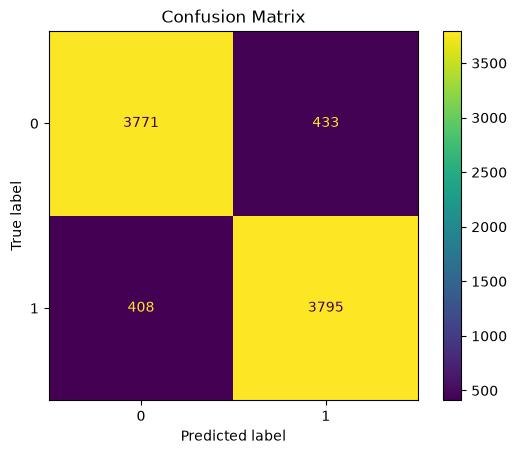

In [91]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(confusion_matrix=cm).plot()

plt.title("Confusion Matrix")

plt.show()

In [92]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X_train_tfidf,
    y_train,
    cv=5
)

print(scores)

print("\nAverage Accuracy:", scores.mean())

[0.90394052 0.90260223 0.90260223 0.90215613 0.90171004]

Average Accuracy: 0.9026022304832715


In [93]:
import joblib

joblib.dump(model, "../trained_model/review_model_v2.pkl")

joblib.dump(tfidf, "../trained_model/tfidf_vectorizer_v2.pkl")

joblib.dump(encoder, "../trained_model/label_encoder.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [94]:
# ==========================================
# Save Final Clean Dataset
# ==========================================

df.to_csv("../dataset/merged/final_reviews_cleaned.csv", index=False)

print("Cleaned dataset saved!")

Cleaned dataset saved!


In [95]:
import pandas as pd

feature_names = tfidf.get_feature_names_out()

coef = model.coef_[0]

top_fake = pd.DataFrame({
    "Word": feature_names,
    "Weight": coef
}).sort_values("Weight")

top_genuine = pd.DataFrame({
    "Word": feature_names,
    "Weight": coef
}).sort_values("Weight", ascending=False)

print("Top Fake Words")
print(top_fake.head(20))

print("\nTop Genuine Words")
print(top_genuine.head(20))

Top Fake Words
                 Word    Weight
3390          chicago -3.868465
17694     reason gave -3.314896
263             admit -3.285031
533         also love -3.169524
13016          luxury -3.166980
16713  problem really -2.986251
16698    problem kind -2.869958
5552         downside -2.824949
20811     story start -2.803227
16136    plastic part -2.678556
3595            clerk -2.674117
18006         replace -2.582001
13391   material good -2.566777
21738     thing would -2.556879
17688          reason -2.550524
12733       love feel -2.480789
10781             iti -2.397791
12231     little hard -2.387006
2380    bought friend -2.344432
10092        huge fan -2.331346

Top Genuine Words
              Word    Weight
21824       though  2.386525
24272      without  2.172128
6364         every  2.096891
6300          even  2.042805
16640        prior  1.952591
15353    otherwise  1.934228
18463        roomy  1.889541
865     appreciate  1.823217
18145     returned  1.819796
9652

In [96]:
top_fake.head(50).to_csv("../reports/top_fake_words.csv", index=False)
top_genuine.head(50).to_csv("../reports/top_genuine_words.csv", index=False)

print("Word reports saved!")

Word reports saved!


In [97]:
review = "Best product ever!!!!! Buy now!!!! Five stars!!!!!"

review_clean = clean_text(review)

vector = tfidf.transform([review_clean])

prediction = model.predict(vector)[0]

label = encoder.inverse_transform([prediction])[0]

print("Prediction:", label)

Prediction: 0


In [98]:
# Merge the datasets
df = pd.concat([df1, df2], ignore_index=True)

print(df.head())
print(df.shape)

                                              review label
0  Love this!  Well made, sturdy, and very comfor...  Fake
1  love it, a great upgrade from the original.  I...  Fake
2  This pillow saved my back. I love the look and...  Fake
3  Missing information on how to use it, but it i...  Fake
4  Very nice set. Good quality. We have had the s...  Fake
(42032, 2)


In [99]:
df.to_csv("../dataset/merged/final_reviews.csv", index=False)

print("Merged dataset saved successfully!")

Merged dataset saved successfully!


In [100]:
df["clean_review"] = df["review"].apply(clean_text)

In [101]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["label"] = encoder.fit_transform(df["label"])

In [102]:
from sklearn.model_selection import train_test_split

X = df["clean_review"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [103]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=25000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [104]:
from sklearn.svm import LinearSVC

model = LinearSVC()

model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [105]:
import joblib

joblib.dump(model, "../trained_model/review_model_v2.pkl")
joblib.dump(tfidf, "../trained_model/tfidf_vectorizer_v2.pkl")
joblib.dump(encoder, "../trained_model/label_encoder.pkl")

print("Model saved successfully!")

Model saved successfully!


In [106]:
print(encoder.classes_)

['Fake' 'Genuine']


In [107]:
review = "Best product ever!!!! Buy now!!!! Five stars!!!!!"

vector = tfidf.transform([review])

pred = model.predict(vector)[0]

print("Prediction number:", pred)
print("Prediction label:", encoder.inverse_transform([pred])[0])

Prediction number: 0
Prediction label: Fake
